In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/AB_NYC_2019.csv")
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [ ]:
# Number of columns and rows
print(f'This DataFrame is having {df.shape[0]} rows and {df.shape[1]} columns.')

This DataFrame is having 48895 rows and 16 columns.


In [ ]:
print(df.head())


     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
print(df.isnull().sum())

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [ ]:
# Handling unnecessary columns
df.drop(
    columns=[
        'id',
        'host_id',
        'name',
        'host_name',
        'last_review'
    ],
    inplace=True
)

In [ ]:
# Handling missing values
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df = df.dropna()
df.drop_duplicates(inplace=True)


In [ ]:
df.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


In [ ]:
df['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [ ]:

df['price_category'] = pd.cut(
    df['price'],
    bins=[0,100,200,500,10000],
    labels=['Budget','Mid','Premium','Luxury']
)

In [ ]:
print("Average Price :", df['price'].mean())
print("Average Reviews :", df['number_of_reviews'].mean())
print("Average Availability :", df['availability_365'].mean())

Average Price : 152.7206871868289
Average Reviews : 23.274465691788528
Average Availability : 112.78132733408324


In [ ]:
# Removing unrealistic data
df = df[(df['price'] > 0) & (df['price'] <= 1000)]
df = df[df['minimum_nights'] <= 365]

In [ ]:
# Create a function to find outliers and apply the function on a DataFrame
def Outliers(data,col):
  q1=data[col].quantile(0.25)
  q3=data[col].quantile(0.75)
  IQR=q3-q1
  lower_fence=q1-1.5*(IQR)
  upper_fence=q3+1.5*(IQR)
  outlier=data[(data[col]<lower_fence)|(data[col]>upper_fence)]
  return lower_fence,upper_fence,outlier

In [ ]:
col = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

for cl in col:
    lf, uf, outlr = Outliers(df, cl)

    print(f"\nColumn : {cl}")
    print("Lower Fence :", lf)
    print("Upper Fence :", uf)
    print("Count of Outliers :", outlr.shape[0])


Column : price
Lower Fence : -90.0
Upper Fence : 334.0
Count of Outliers : 2732

Column : minimum_nights
Lower Fence : -5.0
Upper Fence : 11.0
Count of Outliers : 6532

Column : number_of_reviews
Lower Fence : -33.5
Upper Fence : 58.5
Count of Outliers : 6012

Column : reviews_per_month
Lower Fence : -2.285
Upper Fence : 3.915
Count of Outliers : 3268

Column : calculated_host_listings_count
Lower Fence : -0.5
Upper Fence : 3.5
Count of Outliers : 7028

Column : availability_365
Lower Fence : -337.5
Upper Fence : 562.5
Count of Outliers : 0


In [ ]:
df[['price','minimum_nights']].describe()

,price,minimum_nights
count,48631.000000,48631.000000
mean,141.312866,6.782937
std,116.737448,16.123039
min,10.000000,1.000000
25%,69.000000,1.000000
50%,105.000000,3.000000
75%,175.000000,5.000000
max,1000.000000,365.000000


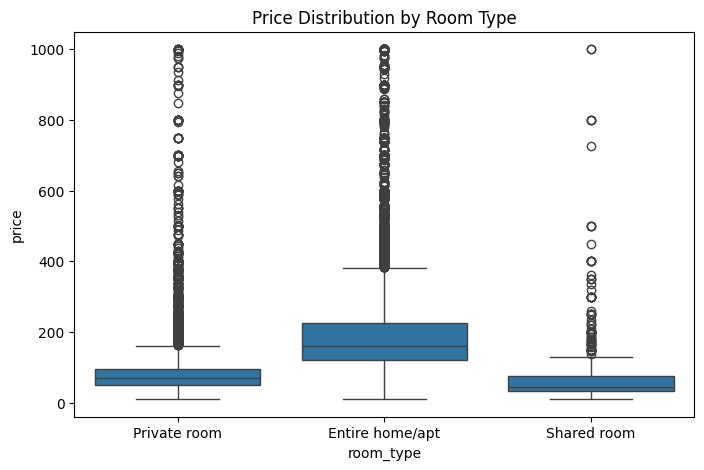

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='room_type',
    y='price',
    data=df,
)

plt.title('Price Distribution by Room Type')
plt.show()

In [ ]:
def remove_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers(df, 'price')

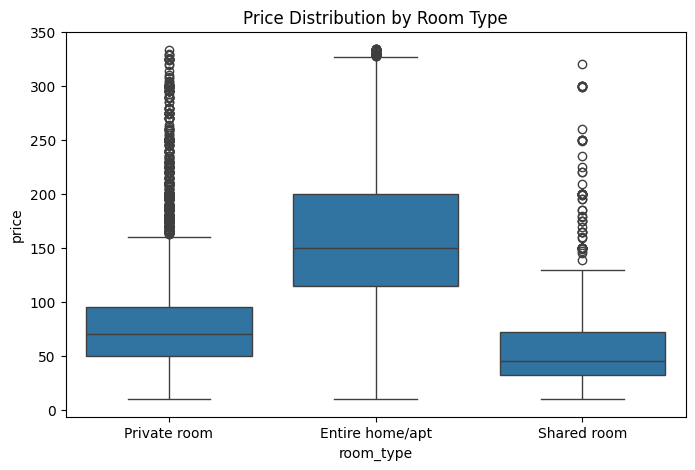

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='room_type',
    y='price',
    data=df,

)

plt.title('Price Distribution by Room Type')
plt.show()

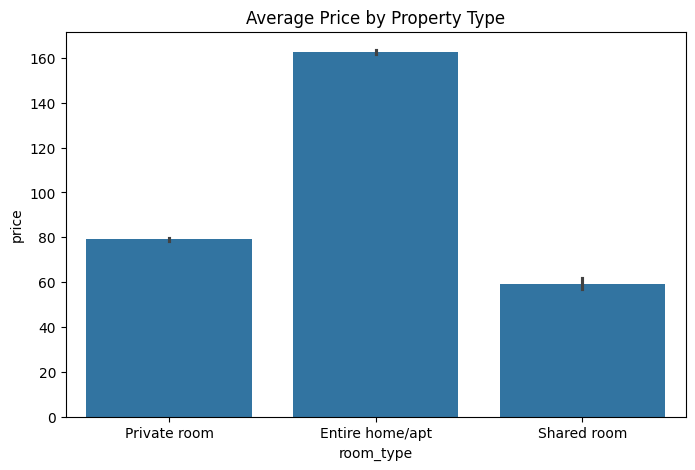

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='room_type',
    y='price',
    data=df,
    estimator='mean'
)

plt.title('Average Price by Property Type')
plt.show()

Entire homes/apartments command significantly higher prices than private or shared rooms, making room type one of the strongest pricing factors.

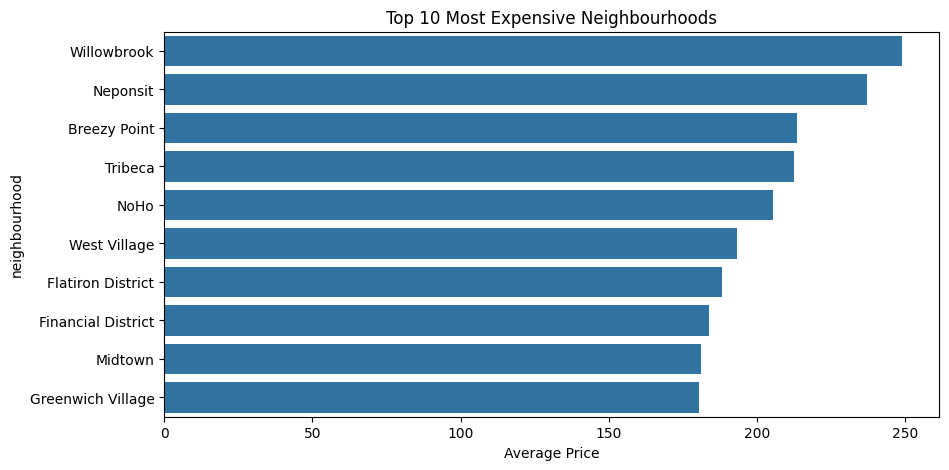

In [ ]:
top10 = (
    df.groupby('neighbourhood')['price']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top10.values, y=top10.index)

plt.title('Top 10 Most Expensive Neighbourhoods')
plt.xlabel('Average Price')
plt.show()

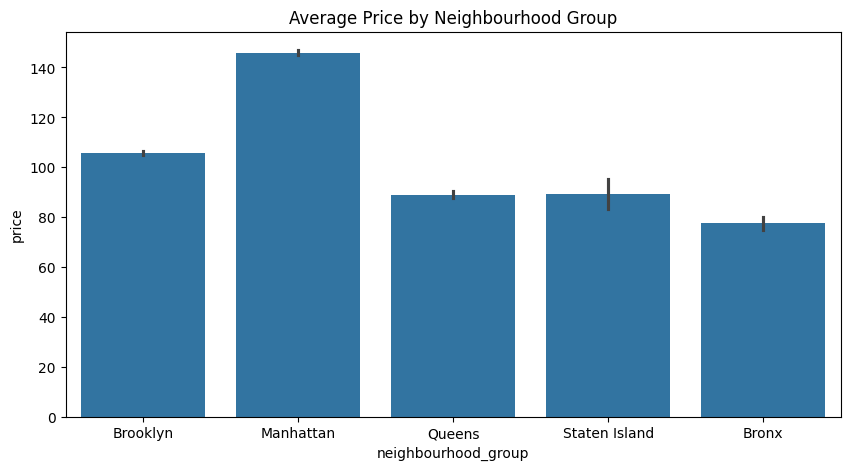

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='neighbourhood_group',
    y='price',
    data=df,
    estimator='mean'
)

plt.title('Average Price by Neighbourhood Group')
plt.show()

Manhattan listings have the highest average prices, reflecting premium demand and location value.

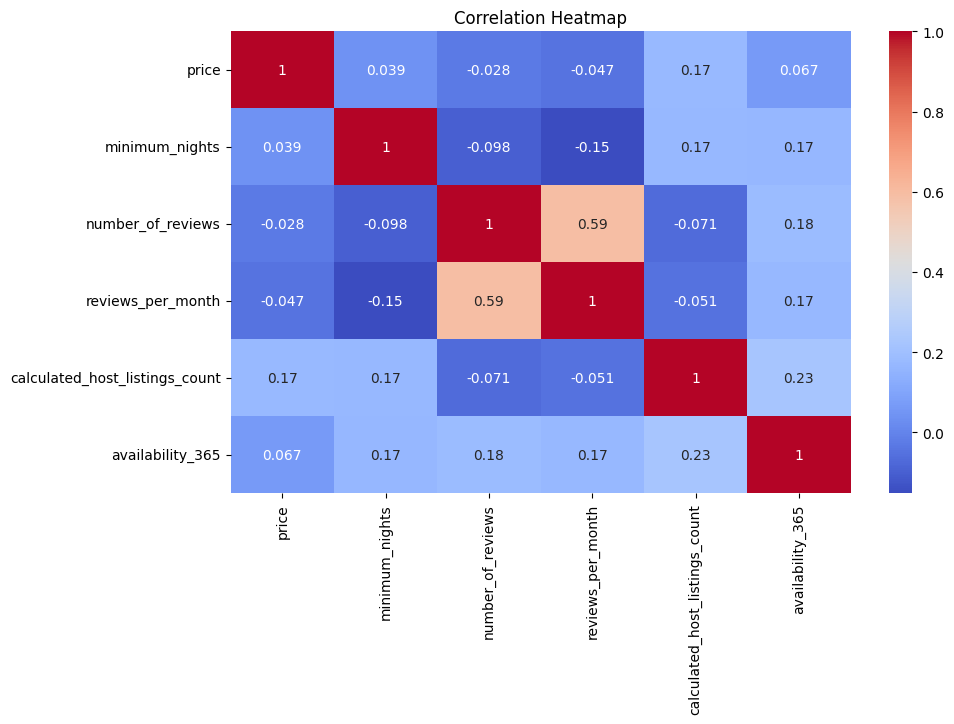

In [ ]:
plt.figure(figsize=(10,6))

corr_cols = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

Price appears to be influenced more by categorical and location-based factors than by review-related metrics.

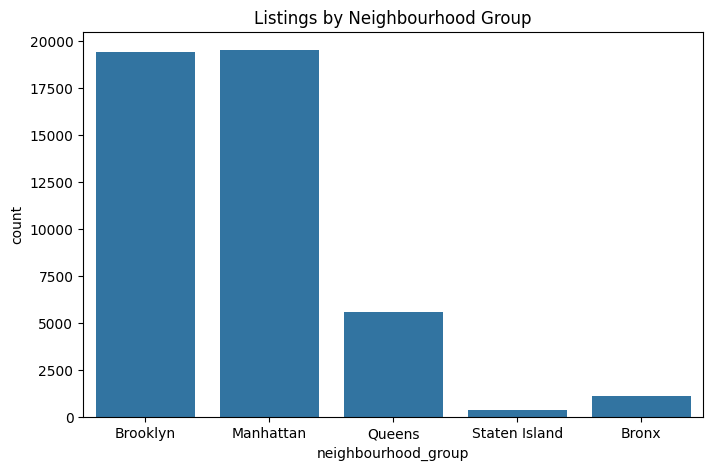

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='neighbourhood_group', data=df)
plt.title('Listings by Neighbourhood Group')
plt.show()

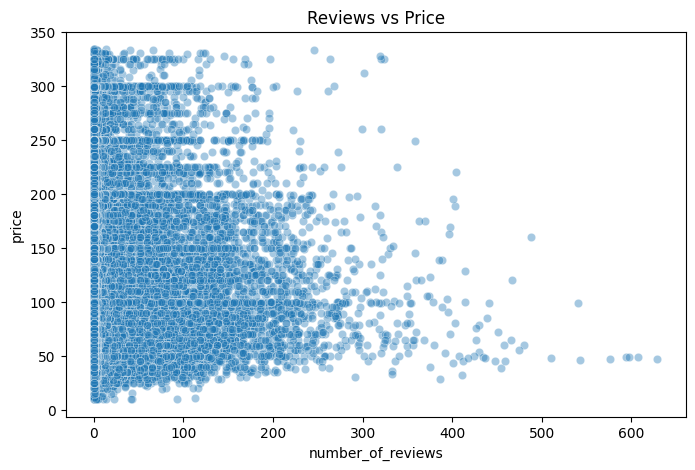

In [ ]:
df_plot = df[df['price'] <= 500]

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='number_of_reviews',
    y='price',
    data=df_plot,
    alpha=0.4
)

plt.title('Reviews vs Price')
plt.show()

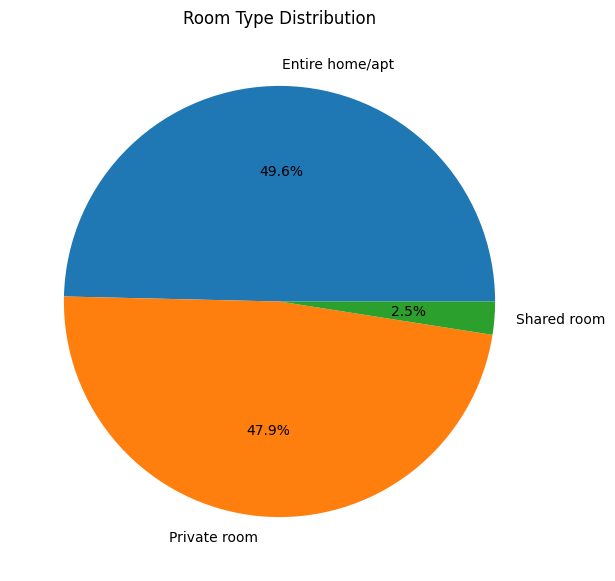

In [ ]:
room_counts = df['room_type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    room_counts,
    labels=room_counts.index,
    autopct='%1.1f%%'
)

plt.title('Room Type Distribution')
plt.show()

Feature engineering


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)

df['location_cluster'] = kmeans.fit_predict(
    df[['latitude', 'longitude']]
)

In [ ]:
df['review_activity'] = (
    df['number_of_reviews'] *
    df['reviews_per_month']
)

In [ ]:
df['host_category'] = pd.cut(
    df['calculated_host_listings_count'],
    bins=[0,1,5,20,500],
    labels=[
        'Single',
        'Small',
        'Medium',
        'Large'
    ]
)

In [ ]:
df[
[
'location_cluster',
'review_activity',
'host_category'
]
].head()

,location_cluster,review_activity,host_category
0,7,1.89,Medium
1,1,17.10,Small
2,2,0.00,Single
3,4,1252.80,Single
4,2,0.90,Single


In [ ]:
features = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
]

X = df[features]

y = df['price']

In [ ]:
X = pd.get_dummies(
    X,
    columns=[
        'neighbourhood_group',
        'neighbourhood',
        'room_type',

    ],
    drop_first=True
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:


from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = mean_squared_error(
        y_true,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, r2

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        evaluate_model(y_test, y_pred_lr)[0],
        evaluate_model(y_test, y_pred_dt)[0],
        evaluate_model(y_test, y_pred_rf)[0]
    ],
    'RMSE': [
        evaluate_model(y_test, y_pred_lr)[1],
        evaluate_model(y_test, y_pred_dt)[1],
        evaluate_model(y_test, y_pred_rf)[1]
    ],
    'R2 Score': [
        evaluate_model(y_test, y_pred_lr)[2],
        evaluate_model(y_test, y_pred_dt)[2],
        evaluate_model(y_test, y_pred_rf)[2]
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,34.631625,47.226426,0.522424
1,Decision Tree,42.610125,60.633183,0.212786
2,Random Forest,32.467951,45.329156,0.560025


Three machine learning models were trained and evaluated for Airbnb price prediction: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

Linear Regression achieved an R² score of 0.52, indicating a moderate linear relationship between the selected features and listing prices.
Decision Tree Regressor achieved an R² score of 0.21, showing poor generalization and a tendency to overfit the training data.
Random Forest Regressor delivered the best performance with an R² score of 0.56, the lowest MAE (32.47) and the lowest RMSE (45.33).

Based on the evaluation metrics, Random Forest Regressor was selected as the final model because it provided the most accurate and reliable price predictions among all tested models.

The results indicate that factors such as location, room type, availability, reviews, and host-related attributes have a significant impact on Airbnb pricing. However, the moderate R² score suggests that additional variables such as property size, amenities, and property ratings could further improve predictive performance.

In [ ]:
best_model = rf

In [ ]:
import joblib

joblib.dump(best_model, "airbnb_price_model.pkl")

['airbnb_price_model.pkl']

In [ ]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [ ]:


joblib.dump(sorted(df['neighbourhood'].unique().tolist()),
            "neighbourhoods.pkl")

['neighbourhoods.pkl']